# Gaussian Process Regression using Scikit-Learn for Energy Efficiency Prediction

This notebook presents an implementation of **Gaussian Process Regression (GPR) using Scikit-Learn** to predict the Heating Load (`Y1`) of buildings. We train GP models using standard kernels and compare their performance against baseline models.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, Matern, RationalQuadratic, DotProduct, ConstantKernel


## 2. Dataset Ingestion and Inspection


In [2]:
df = pd.read_csv('ENB2012_data.csv')
print("Dataset Shape:", df.shape)
print(df.head())


Dataset Shape: (768, 10)
     X1     X2     X3      X4   X5  X6   X7  X8     Y1     Y2
0  0.98  514.5  294.0  110.25  7.0   2  0.0   0  15.55  21.33
1  0.98  514.5  294.0  110.25  7.0   3  0.0   0  15.55  21.33
2  0.98  514.5  294.0  110.25  7.0   4  0.0   0  15.55  21.33
3  0.98  514.5  294.0  110.25  7.0   5  0.0   0  15.55  21.33
4  0.90  563.5  318.5  122.50  7.0   2  0.0   0  20.84  28.28


In [3]:
X = df.iloc[:, :-2].values
Y = df['Y1'].values
print("Features shape:", X.shape)
print("Target shape:", Y.shape)


Features shape: (768, 8)
Target shape: (768,)


### 2.3 Train-Test Split & Feature Z-score Standardization

We split the data randomly (60/40) and standardize the features using only the training set statistics to prevent data leakage.


In [4]:
np.random.seed(42)
indices = np.random.permutation(len(X))
train_size = int(0.6 * len(X))

X_train_raw = X[indices[:train_size]]
X_test_raw = X[indices[train_size:]]
Y_train_orig = Y[indices[:train_size]]
Y_test_orig = Y[indices[train_size:]]

# Standardization parameters from training set
X_mean = np.mean(X_train_raw, axis=0)
X_std = np.std(X_train_raw, axis=0) + 1e-8
X_train = (X_train_raw - X_mean) / X_std
X_test = (X_test_raw - X_mean) / X_std

Y_mean = np.mean(Y_train_orig)
Y_std = np.std(Y_train_orig) + 1e-8
Y_train_norm = (Y_train_orig - Y_mean) / Y_std
Y_test_norm = (Y_test_orig - Y_mean) / Y_std

print(f"Training set: {X_train.shape}, Test set: {X_test.shape}")


Training set: (460, 8), Test set: (308, 8)


### 2.4 Calculating Noise Variance dynamically from Dataset

We fit a multiple linear regression model to the standardized training data and estimate the noise variance as the variance of the training residuals.


In [5]:
X_tr_b = np.hstack([np.ones((len(X_train), 1)), X_train])
w_noise = np.linalg.solve(X_tr_b.T @ X_tr_b + 1e-8 * np.eye(X_tr_b.shape[1]), X_tr_b.T @ Y_train_norm)
noise = np.var(Y_train_norm - X_tr_b @ w_noise)
print("Estimated Noise Variance (sigma_n^2):", noise)


Estimated Noise Variance (sigma_n^2): 0.08587998114645025


## 3. GPR Implementation with RBF Kernel


In [6]:
kernel = ConstantKernel(1.0, "fixed") * RBF(length_scale=1.5, length_scale_bounds="fixed")


In [7]:
gpr = GaussianProcessRegressor(kernel=kernel, alpha=noise, optimizer=None, normalize_y=True, random_state=42)
gpr.fit(X_train, Y_train_orig)
print("Learned Kernel (Fixed):", gpr.kernel_)


Learned Kernel (Fixed): 1**2 * RBF(length_scale=1.5)


In [8]:
posterior_mean, posterior_std = gpr.predict(X_test, return_std=True)
lower = posterior_mean - 1.96 * posterior_std
upper = posterior_mean + 1.96 * posterior_std


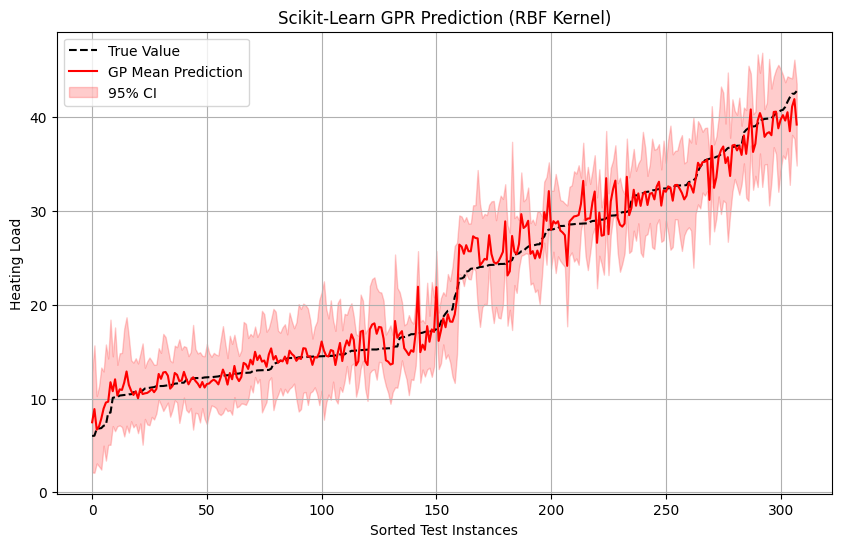

In [9]:
sort_idx = np.argsort(Y_test_orig)
Y_test_sorted = Y_test_orig[sort_idx]
x_axis = np.arange(len(Y_test_sorted))

plt.figure(figsize=(10,6))
plt.plot(x_axis, Y_test_sorted, 'k--', label='True Value', linewidth=1.5)
plt.plot(x_axis, posterior_mean[sort_idx], 'r-', label='GP Mean Prediction', linewidth=1.5)
plt.fill_between(x_axis, lower[sort_idx], upper[sort_idx], color='red', alpha=0.2, label='95% CI')
plt.xlabel("Sorted Test Instances")
plt.ylabel("Heating Load")
plt.title("Scikit-Learn GPR Prediction (RBF Kernel)")
plt.legend()
plt.grid(True)
plt.show()


### 3.4 Quantifying Prediction Performance (RMSE, MAE, R², NLL)


In [10]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
rmse = np.sqrt(mean_squared_error(Y_test_orig, posterior_mean))
mae = mean_absolute_error(Y_test_orig, posterior_mean)
r2 = r2_score(Y_test_orig, posterior_mean)

from scipy.stats import norm
nll = -np.mean(norm.logpdf(Y_test_orig, loc=posterior_mean, scale=posterior_std))

print("RMSE =", rmse)
print("MAE =", mae)
print("R2 =", r2)
print("NLL =", nll)


RMSE = 1.5425727070379371
MAE = 1.148538714546079
R2 = 0.9755185237951021
NLL = 1.9381349450635643


## 5. Comparison of Covariance Functions (GPML Chapter 4)

We set up a dictionary of six GPR kernels in Scikit-Learn.


In [11]:
kernels = {
    "RBF": ConstantKernel(1.0, "fixed") * RBF(length_scale=1.5, length_scale_bounds="fixed"),
    "Matern32": ConstantKernel(1.0, "fixed") * Matern(length_scale=1.5, length_scale_bounds="fixed", nu=1.5),
    "Matern52": ConstantKernel(1.0, "fixed") * Matern(length_scale=1.5, length_scale_bounds="fixed", nu=2.5),
    "RQ": ConstantKernel(1.0, "fixed") * RationalQuadratic(length_scale=1.5, length_scale_bounds="fixed", alpha=2.0, alpha_bounds="fixed"),
    "Linear": ConstantKernel(1.0, "fixed") * DotProduct(sigma_0=1.0, sigma_0_bounds="fixed"),
    "RBF+RQ (Hybrid)": ConstantKernel(1.0, "fixed") * RBF(length_scale=1.5, length_scale_bounds="fixed") + ConstantKernel(1.0, "fixed") * RationalQuadratic(length_scale=1.5, length_scale_bounds="fixed", alpha=1.5, alpha_bounds="fixed")
}


In [12]:
results = {}
for name, kernel in kernels.items():
    gpr_k = GaussianProcessRegressor(kernel=kernel, alpha=noise, optimizer=None, normalize_y=True, random_state=42)
    gpr_k.fit(X_train, Y_train_orig)
    mean, std = gpr_k.predict(X_test, return_std=True)
    results[name] = {
        "mean": mean,
        "variance": std ** 2
    }
    print(f"Scikit-Learn GP with {name} kernel trained.")


Scikit-Learn GP with RBF kernel trained.
Scikit-Learn GP with Matern32 kernel trained.
Scikit-Learn GP with Matern52 kernel trained.
Scikit-Learn GP with RQ kernel trained.
Scikit-Learn GP with Linear kernel trained.
Scikit-Learn GP with RBF+RQ (Hybrid) kernel trained.


In [13]:
from scipy.stats import norm
comparison = []
for name in results.keys():
    pred = results[name]["mean"]
    variance = results[name]["variance"]
    std = np.sqrt(variance)
    
    rmse = np.sqrt(mean_squared_error(Y_test_orig, pred))
    mae = mean_absolute_error(Y_test_orig, pred)
    r2 = r2_score(Y_test_orig, pred)
    nll = -np.mean(norm.logpdf(Y_test_orig, loc=pred, scale=std))
    
    comparison.append([name, rmse, mae, r2, nll])

comparison_df = pd.DataFrame(
    comparison,
    columns=["Kernel", "RMSE", "MAE", "R2", "NLL"]
)
comparison_df = comparison_df.sort_values("RMSE")
print(comparison_df)


            Kernel      RMSE       MAE        R2        NLL
5  RBF+RQ (Hybrid)  1.310292  0.942154  0.982336   2.036198
2         Matern52  1.524127  1.087298  0.976101   2.214354
3               RQ  1.541599  1.105377  0.975549   2.009800
0              RBF  1.542573  1.148539  0.975519   1.938135
1         Matern32  1.619858  1.155158  0.973004   2.419979
4           Linear  2.836373  2.002857  0.917230  28.631743


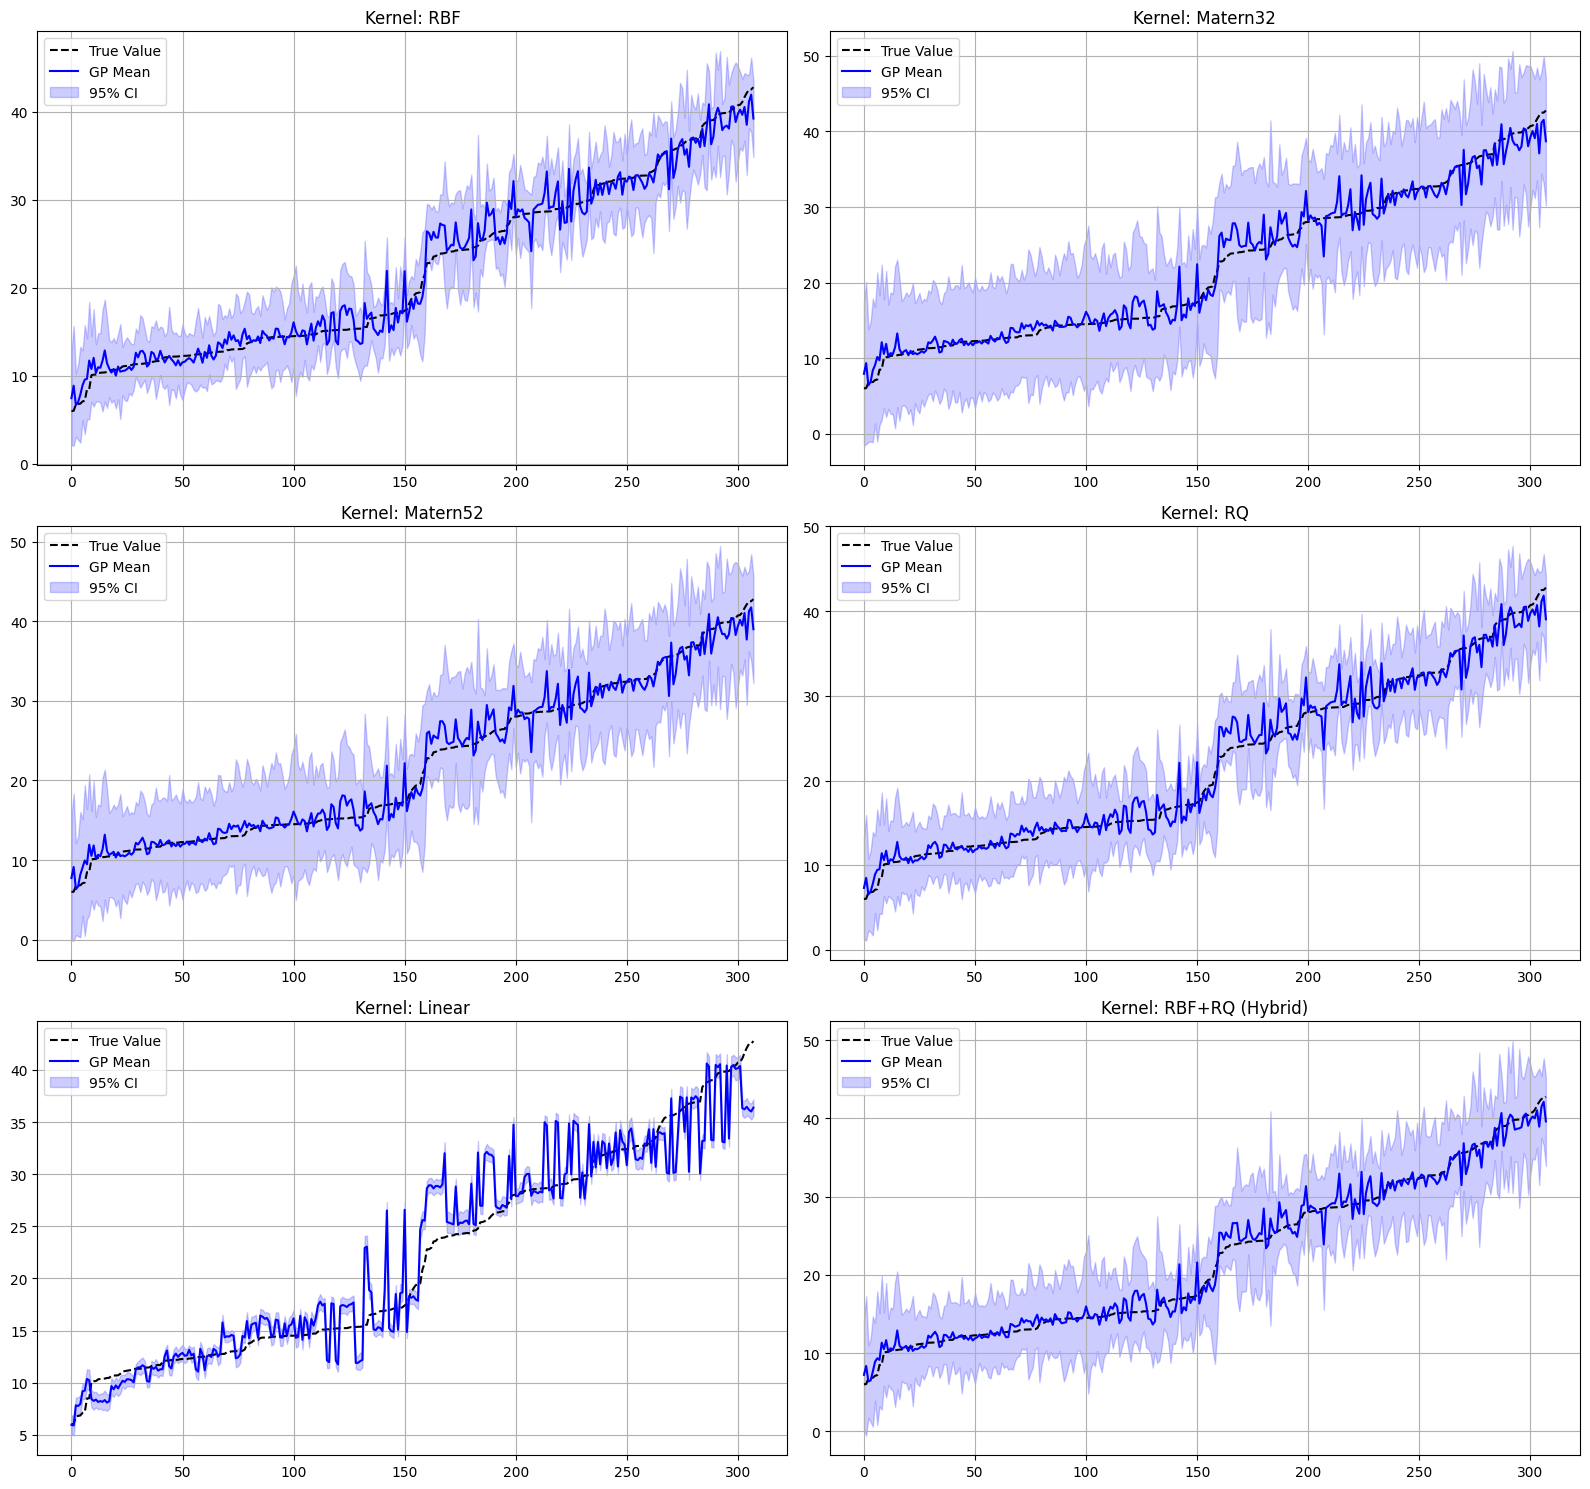

In [14]:
fig, axes = plt.subplots(3, 2, figsize=(16, 15))
axes = axes.flatten()
for idx, name in enumerate(results.keys()):
    ax = axes[idx]
    pred = results[name]["mean"]
    std = np.sqrt(results[name]["variance"])
    pred_s = pred[sort_idx]
    std_s = std[sort_idx]
    
    ax.plot(x_axis, Y_test_sorted, 'k--', label='True Value')
    ax.plot(x_axis, pred_s, 'b-', label='GP Mean')
    ax.fill_between(x_axis, pred_s - 1.96*std_s, pred_s + 1.96*std_s, color='blue', alpha=0.2, label='95% CI')
    ax.set_title(f"Kernel: {name}")
    ax.legend()
    ax.grid(True)
plt.tight_layout()
plt.show()


## 6. Comparison with Baseline Machine Learning Models

We implement baseline regressors (Linear Regression, Polynomial Regression, KNN, and Decision Tree) using standard Scikit-Learn implementations.


In [15]:
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor

class PolynomialRegressionSklearn:
    def __init__(self, degree=2):
        self.degree = degree
        self.model = LinearRegression()
    def fit(self, X, y):
        features = [X**i for i in range(1, self.degree + 1)]
        X_poly = np.hstack(features)
        self.model.fit(X_poly, y)
    def predict(self, X):
        features = [X**i for i in range(1, self.degree + 1)]
        X_poly = np.hstack(features)
        return self.model.predict(X_poly)

models_baseline = {
    "Linear Regression": LinearRegression(),
    "Polynomial Regression (Deg 2)": PolynomialRegressionSklearn(degree=2),
    "K-Nearest Neighbors": KNeighborsRegressor(n_neighbors=5),
    "Decision Tree": DecisionTreeRegressor(max_depth=5, random_state=42)
}

trained_baselines = {}
for name, model in models_baseline.items():
    model.fit(X_train, Y_train_orig)
    trained_baselines[name] = model
    print(f"Baseline '{name}' trained successfully.")


Baseline 'Linear Regression' trained successfully.
Baseline 'Polynomial Regression (Deg 2)' trained successfully.
Baseline 'K-Nearest Neighbors' trained successfully.
Baseline 'Decision Tree' trained successfully.


In [16]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error

baseline_results = []
for name, model in trained_baselines.items():
    y_pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(Y_test_orig, y_pred))
    mae = mean_absolute_error(Y_test_orig, y_pred)
    r2 = r2_score(Y_test_orig, y_pred)
    mape = mean_absolute_percentage_error(Y_test_orig, y_pred)
    baseline_results.append([name, rmse, mae, r2, mape])

baseline_df = pd.DataFrame(
    baseline_results,
    columns=["Model", "RMSE", "MAE", "R2", "MAPE"]
)
baseline_df = baseline_df.sort_values("RMSE")
print(baseline_df)


                           Model      RMSE       MAE        R2      MAPE
3                  Decision Tree  1.037341  0.691548  0.988929  0.028875
1  Polynomial Regression (Deg 2)  2.420561  1.976888  0.939719  0.109384
2            K-Nearest Neighbors  2.491383  1.610474  0.936140  0.075498
0              Linear Regression  2.837534  2.005220  0.917162  0.097821


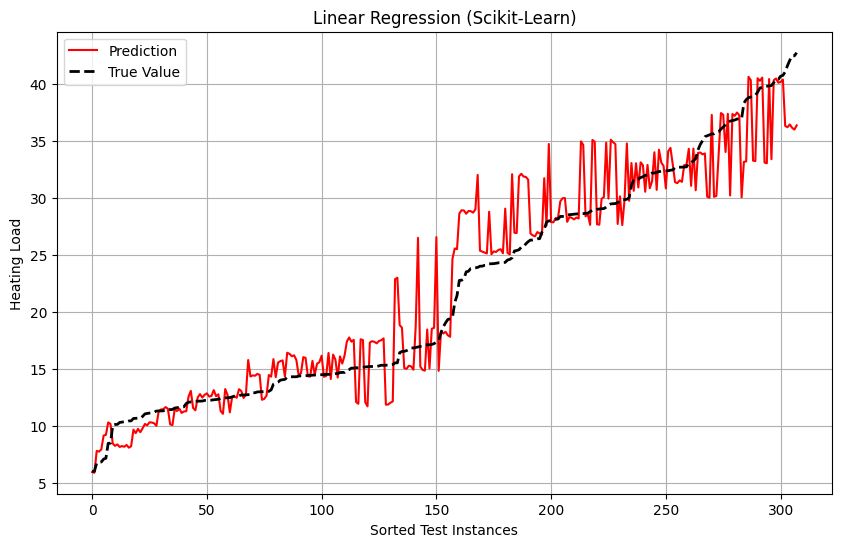

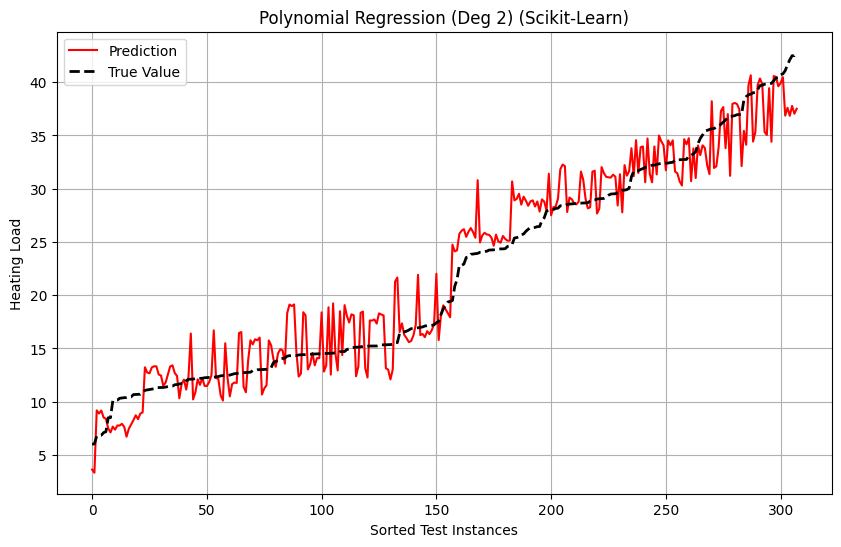

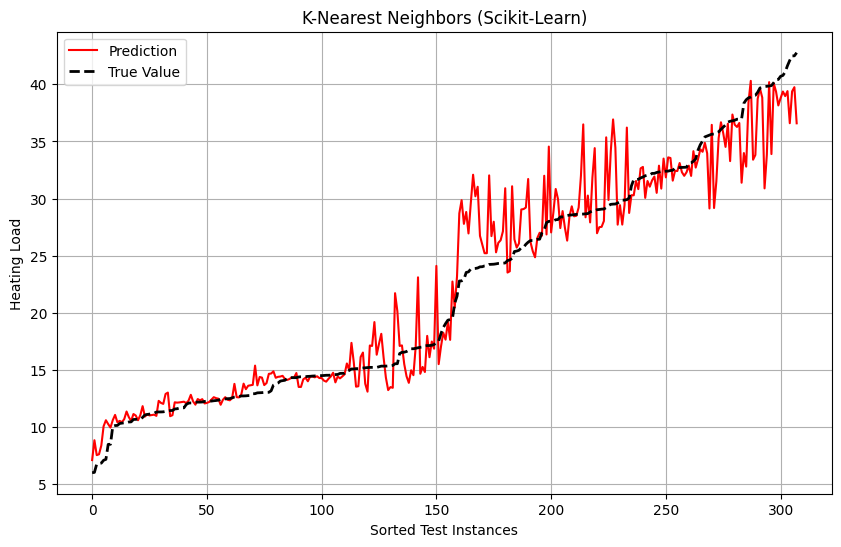

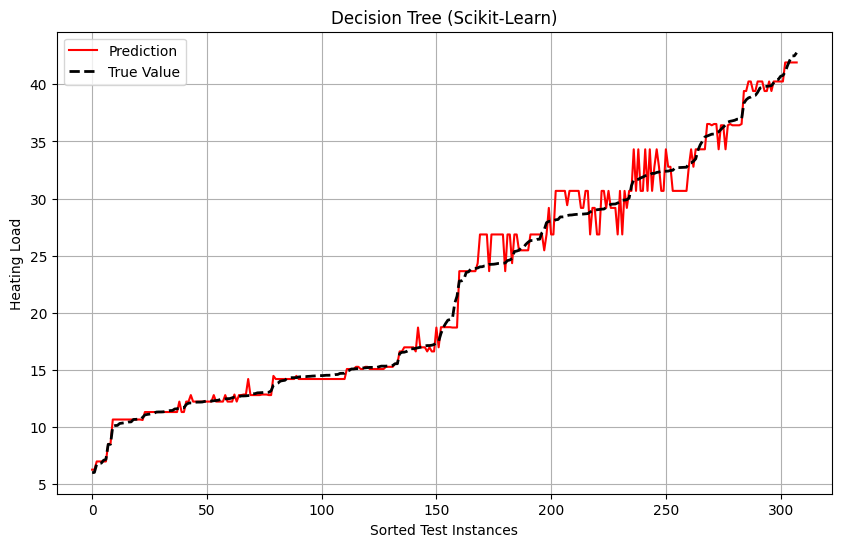

In [17]:
for name, model in trained_baselines.items():
    y_pred = model.predict(X_test)
    plt.figure(figsize=(10,6))
    plt.plot(x_axis, y_pred[sort_idx], 'r-', label='Prediction', linewidth=1.5)
    plt.plot(x_axis, Y_test_sorted, 'k--', label='True Value', linewidth=2.0)
    plt.title(f"{name} (Scikit-Learn)")
    plt.xlabel("Sorted Test Instances")
    plt.ylabel("Heating Load")
    plt.legend()
    plt.grid(True)
    plt.show()


## 7. Summary and Model Ranking


In [18]:
joint_results = []
for name in results.keys():
    pred = results[name]["mean"]
    rmse = np.sqrt(mean_squared_error(Y_test_orig, pred))
    mape = mean_absolute_percentage_error(Y_test_orig, pred)
    accuracy = 100 * (1 - mape)
    joint_results.append([f"GPR ({name})", rmse, accuracy])
    
for name, model in trained_baselines.items():
    pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(Y_test_orig, pred))
    mape = mean_absolute_percentage_error(Y_test_orig, pred)
    accuracy = 100 * (1 - mape)
    joint_results.append([name, rmse, accuracy])
    
ranking_df = pd.DataFrame(joint_results, columns=["Model", "RMSE", "Accuracy (%)"])
ranking_df = ranking_df.sort_values("RMSE")
print(ranking_df)


                           Model      RMSE  Accuracy (%)
9                  Decision Tree  1.037341     97.112524
5          GPR (RBF+RQ (Hybrid))  1.310292     94.982488
2                 GPR (Matern52)  1.524127     94.297399
3                       GPR (RQ)  1.541599     94.301699
0                      GPR (RBF)  1.542573     93.907057
1                 GPR (Matern32)  1.619858     94.008274
7  Polynomial Regression (Deg 2)  2.420561     89.061583
8            K-Nearest Neighbors  2.491383     92.450172
4                   GPR (Linear)  2.836373     90.223182
6              Linear Regression  2.837534     90.217882


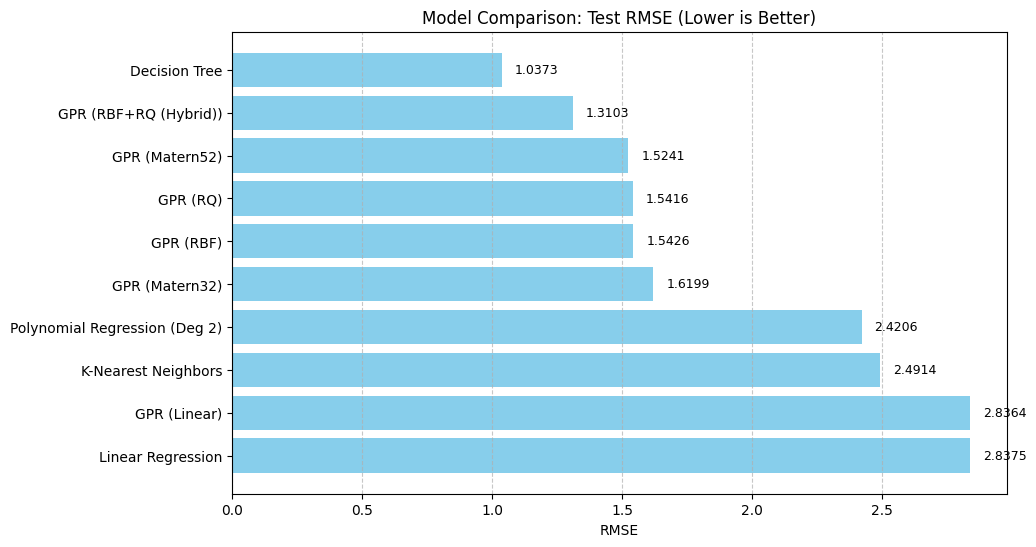

In [19]:
ranking_df_sorted_rmse = ranking_df.sort_values("RMSE", ascending=True)
plt.figure(figsize=(10,6))
bars = plt.barh(ranking_df_sorted_rmse["Model"], ranking_df_sorted_rmse["RMSE"], color='skyblue')
plt.xlabel("RMSE")
plt.title("Model Comparison: Test RMSE (Lower is Better)")
plt.gca().invert_yaxis()
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.05, bar.get_y() + bar.get_height()/2, f"{width:.4f}", 
             va='center', ha='left', fontsize=9)
plt.grid(True, axis='x', linestyle='--', alpha=0.7)
plt.show()


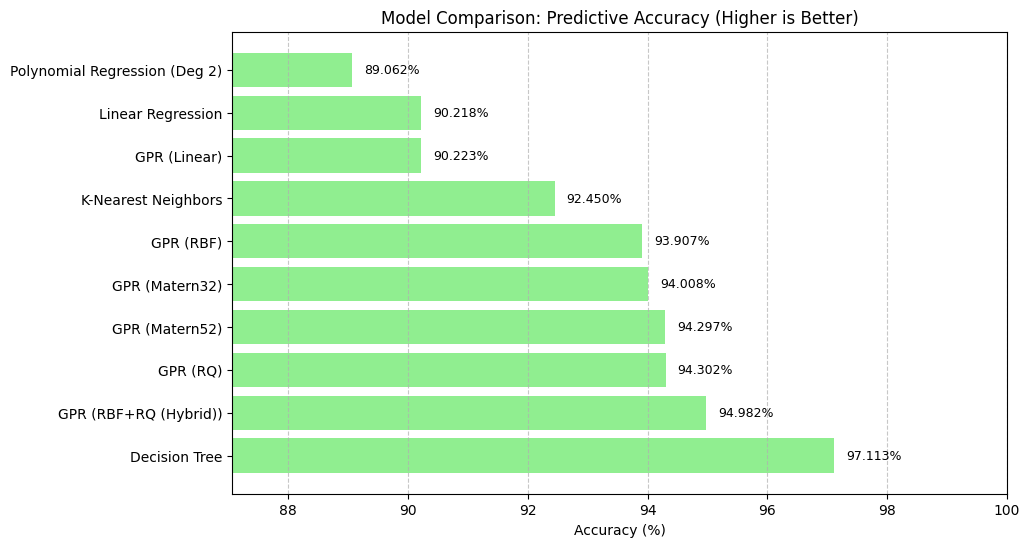

In [20]:
ranking_df_sorted_acc = ranking_df.sort_values("Accuracy (%)", ascending=False)
plt.figure(figsize=(10,6))
bars = plt.barh(ranking_df_sorted_acc["Model"], ranking_df_sorted_acc["Accuracy (%)"], color='lightgreen')
plt.xlabel("Accuracy (%)")
plt.title("Model Comparison: Predictive Accuracy (Higher is Better)")
plt.xlim(ranking_df["Accuracy (%)"].min() - 2, 100)
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.2, bar.get_y() + bar.get_height()/2, f"{width:.3f}%", 
             va='center', ha='left', fontsize=9)
plt.grid(True, axis='x', linestyle='--', alpha=0.7)
plt.show()
